In [ ]:
# ── CELL 1: Install & import everything ─────────────────────────────────────
!pip install pandas matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import f1_score, classification_report
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings('ignore')
print('All libraries loaded')

All libraries loaded


In [ ]:
# ── CELL 2: Upload CSV files ──────────────────────────────────────────────────
from google.colab import files

print('Upload BOTH CSV files at the same time')
uploaded = files.upload()

df1_raw = pd.read_csv('task1_gecs_classification_final.csv')
df2_raw = pd.read_csv('task2_subindustry_classification_final.csv')

print(f'Task 1 loaded: {len(df1_raw):,} rows')
print(f'Task 2 loaded: {len(df2_raw):,} rows')

Upload BOTH CSV files at the same time


Saving task1_gecs_classification_final.csv to task1_gecs_classification_final.csv
Saving task2_subindustry_classification_final.csv to task2_subindustry_classification_final.csv
Task 1 loaded: 53,585 rows
Task 2 loaded: 27,537 rows


In [ ]:
# ── CELL 3: Null analysis ─────────────────────────────────────────────────────
print('='*55)
print('TASK 1 — NULL / MISSING VALUE REPORT')
print('='*55)
for col in df1_raw.columns:
    nulls = df1_raw[col].isnull().sum() + (df1_raw[col] == '').sum()
    pct   = nulls / len(df1_raw) * 100
    flag  = '⚠️ ' if pct > 0 else '  '
    print(f'  {flag} {col:<40} {nulls:>7,}  ({pct:.1f}%)')

print()
print('='*55)
print('TASK 2 — NULL / MISSING VALUE REPORT')
print('='*55)
for col in df2_raw.columns:
    nulls = df2_raw[col].isnull().sum() + (df2_raw[col] == '').sum()
    pct   = nulls / len(df2_raw) * 100
    flag  = '⚠️ ' if pct > 0 else '  '
    print(f'  {flag} {col:<40} {nulls:>7,}  ({pct:.1f}%)')

TASK 1 — NULL / MISSING VALUE REPORT
     CompanyId                                      0  (0.0%)
     AsOfDate                                       0  (0.0%)
     LongProfile                                    0  (0.0%)
     SegmentName                                    0  (0.0%)
  ⚠️  SegmentDescription                        27,524  (51.4%)
     Revenue                                        0  (0.0%)
     total_revenue_company_as_of                    0  (0.0%)
     revenue_share                                  0  (0.0%)
     is_largest_share_segment                       0  (0.0%)
     MstarGlobal                                    0  (0.0%)

TASK 2 — NULL / MISSING VALUE REPORT
     CompanyId                                      0  (0.0%)
     AsOfDate                                       0  (0.0%)
     SegmentName                                    0  (0.0%)
     SegmentDescription                             0  (0.0%)
     SubIndustry                                    0  

In [ ]:
# ── CELL 4: Data cleaning ─────────────────────────────────────────────────────
df1 = df1_raw.copy()
df1 = df1.dropna(subset=['LongProfile'])
df1 = df1[df1['LongProfile'].str.split().str.len() >= 5]
df1 = df1.dropna(subset=['MstarGlobal'])
df1['SegmentDescription'] = df1['SegmentDescription'].fillna('')
df1['SegmentName']        = df1['SegmentName'].fillna('')
df1['revenue_share']      = pd.to_numeric(df1['revenue_share'], errors='coerce').clip(0,1).fillna(0)
df1['is_largest_flag']    = (df1['is_largest_share_segment'].astype(str).str.strip() == 'True').astype(int)

df2 = df2_raw.copy()
df2['SegmentDescription'] = df2['SegmentDescription'].fillna('')
df2['SegmentName']        = df2['SegmentName'].fillna('')
df2 = df2.dropna(subset=['SubIndustry'])
df2['SubIndustry']        = df2['SubIndustry'].astype(str)

print(f'Task 1: {len(df1):,} rows | Task 2: {len(df2):,} rows')
print('Cleaning complete')

Task 1: 53,585 rows | Task 2: 27,537 rows
Cleaning complete


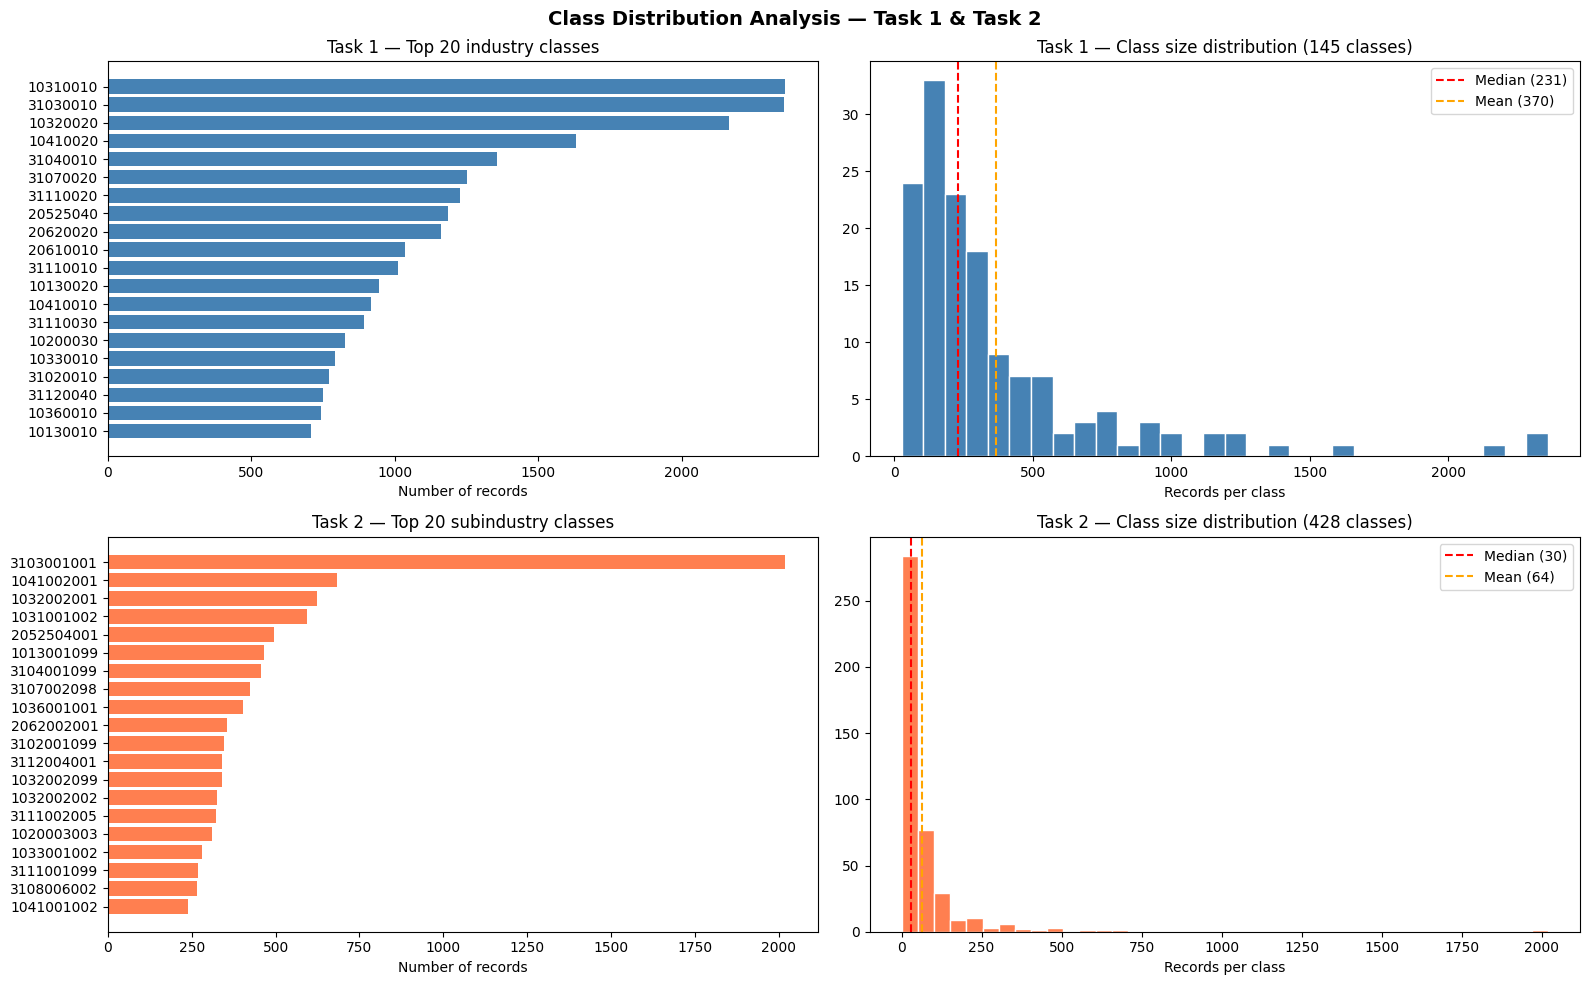

Task 1 — imbalance ratio: 84.2x  |  median: 231
Task 2 — imbalance ratio: 2018.0x  |  median: 30  |  singletons: 21
Saved: desc_class_distributions.png


In [ ]:
# ── CELL 5: Descriptive analysis — class distributions ───────────────────────
cc1 = df1['MstarGlobal'].value_counts()
cc2 = df2['SubIndustry'].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Class Distribution Analysis — Task 1 & Task 2', fontsize=14, fontweight='bold')

axes[0,0].barh(cc1.head(20).index.astype(str), cc1.head(20).values, color='steelblue')
axes[0,0].set_title('Task 1 — Top 20 industry classes')
axes[0,0].set_xlabel('Number of records')
axes[0,0].invert_yaxis()

axes[0,1].hist(cc1.values, bins=30, color='steelblue', edgecolor='white')
axes[0,1].axvline(cc1.median(), color='red',    linestyle='--', label=f'Median ({cc1.median():.0f})')
axes[0,1].axvline(cc1.mean(),   color='orange', linestyle='--', label=f'Mean ({cc1.mean():.0f})')
axes[0,1].set_title('Task 1 — Class size distribution (145 classes)')
axes[0,1].set_xlabel('Records per class')
axes[0,1].legend()

axes[1,0].barh(cc2.head(20).index.astype(str), cc2.head(20).values, color='coral')
axes[1,0].set_title('Task 2 — Top 20 subindustry classes')
axes[1,0].set_xlabel('Number of records')
axes[1,0].invert_yaxis()

axes[1,1].hist(cc2.values, bins=40, color='coral', edgecolor='white')
axes[1,1].axvline(cc2.median(), color='red',    linestyle='--', label=f'Median ({cc2.median():.0f})')
axes[1,1].axvline(cc2.mean(),   color='orange', linestyle='--', label=f'Mean ({cc2.mean():.0f})')
axes[1,1].set_title('Task 2 — Class size distribution (428 classes)')
axes[1,1].set_xlabel('Records per class')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('desc_class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Task 1 — imbalance ratio: {cc1.max()/cc1.min():.1f}x  |  median: {cc1.median():.0f}')
print(f'Task 2 — imbalance ratio: {cc2.max()/cc2.min():.1f}x  |  median: {cc2.median():.0f}  |  singletons: {(cc2==1).sum()}')
print('Saved: desc_class_distributions.png')

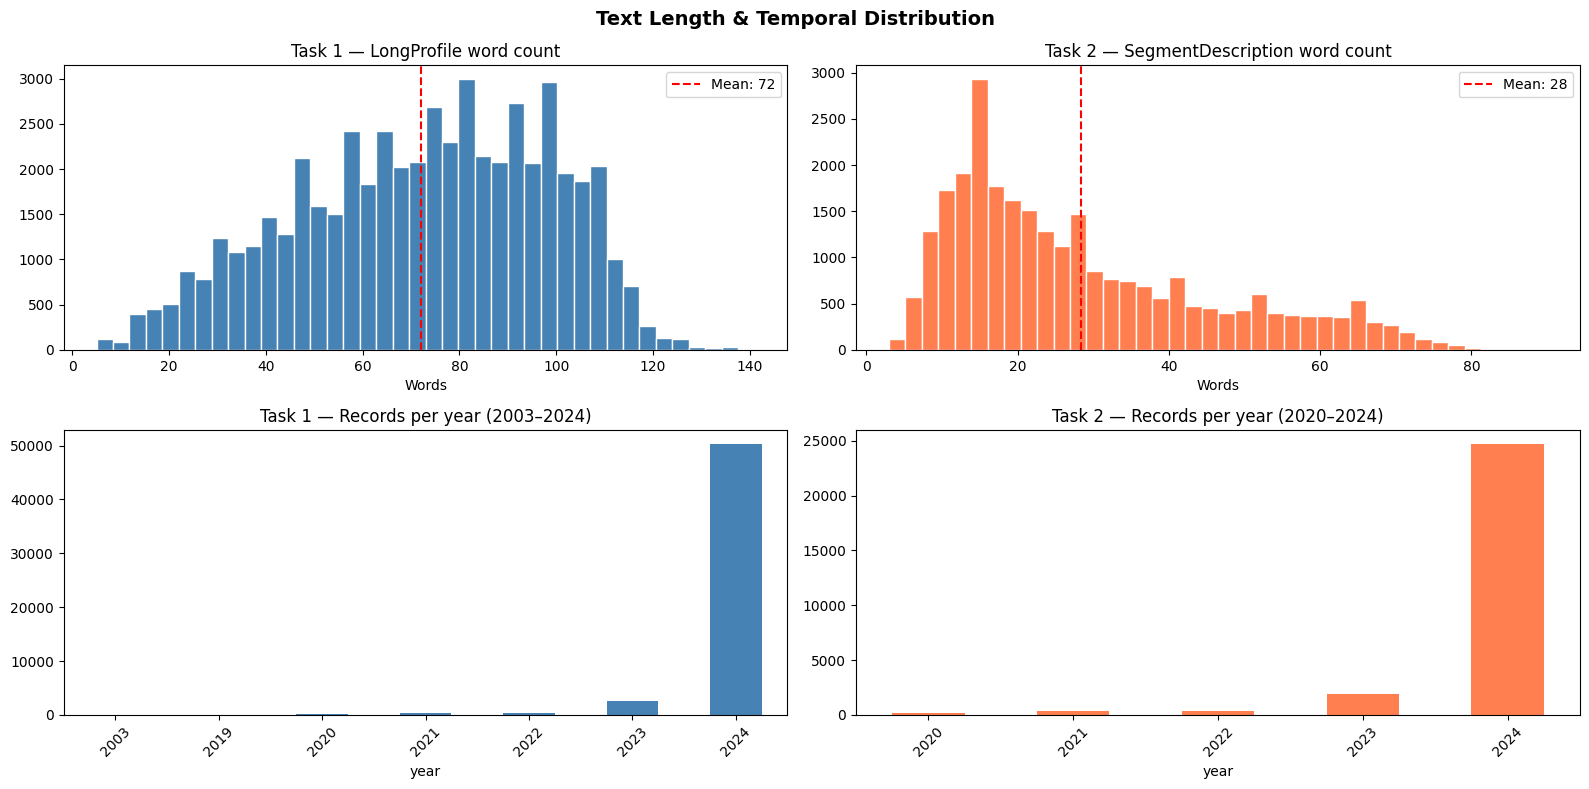

Saved: desc_text_and_time.png


In [ ]:
# ── CELL 6: Descriptive analysis — text lengths & records over time ───────────
df1['lp_words']  = df1['LongProfile'].str.split().str.len()
df1['seg_words'] = df1['SegmentDescription'].str.split().str.len()
df1['year']      = pd.to_datetime(df1['AsOfDate']).dt.year
df2['seg_words'] = df2['SegmentDescription'].str.split().str.len()
df2['year']      = pd.to_datetime(df2['AsOfDate']).dt.year

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Text Length & Temporal Distribution', fontsize=14, fontweight='bold')

axes[0,0].hist(df1['lp_words'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].axvline(df1['lp_words'].mean(), color='red', linestyle='--', label=f'Mean: {df1["lp_words"].mean():.0f}')
axes[0,0].set_title('Task 1 — LongProfile word count')
axes[0,0].set_xlabel('Words')
axes[0,0].legend()

axes[0,1].hist(df2['seg_words'], bins=40, color='coral', edgecolor='white')
axes[0,1].axvline(df2['seg_words'].mean(), color='red', linestyle='--', label=f'Mean: {df2["seg_words"].mean():.0f}')
axes[0,1].set_title('Task 2 — SegmentDescription word count')
axes[0,1].set_xlabel('Words')
axes[0,1].legend()

df1.groupby('year').size().plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Task 1 — Records per year (2003–2024)')
axes[1,0].tick_params(axis='x', rotation=45)

df2.groupby('year').size().plot(kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Task 2 — Records per year (2020–2024)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('desc_text_and_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: desc_text_and_time.png')

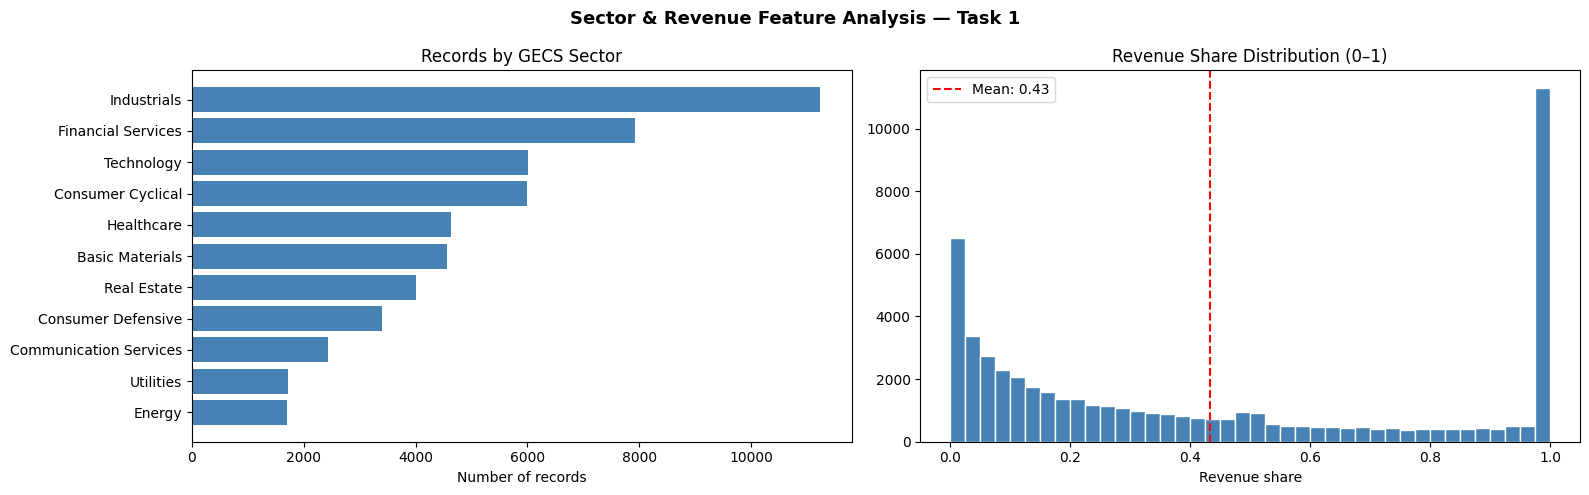

Saved: desc_sector_revenue.png


In [ ]:
# ── CELL 7: Descriptive analysis — sector breakdown ──────────────────────────
sector_map = {
    '101': 'Basic Materials',      '102': 'Consumer Cyclical',
    '103': 'Financial Services',   '104': 'Real Estate',
    '205': 'Consumer Defensive',   '206': 'Healthcare',
    '207': 'Utilities',            '308': 'Communication Services',
    '309': 'Energy',               '310': 'Industrials',
    '311': 'Technology'
}
df1['sector_code'] = df1['MstarGlobal'].astype(str).str[:3]
df1['sector_name'] = df1['sector_code'].map(sector_map).fillna('Other')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Sector & Revenue Feature Analysis — Task 1', fontsize=13, fontweight='bold')

sector_counts = df1['sector_name'].value_counts().sort_values()
axes[0].barh(sector_counts.index, sector_counts.values, color='steelblue')
axes[0].set_title('Records by GECS Sector')
axes[0].set_xlabel('Number of records')

axes[1].hist(df1['revenue_share'].clip(0,1), bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(df1['revenue_share'].mean(), color='red', linestyle='--',
                label=f'Mean: {df1["revenue_share"].mean():.2f}')
axes[1].set_title('Revenue Share Distribution (0–1)')
axes[1].set_xlabel('Revenue share')
axes[1].legend()

plt.tight_layout()
plt.savefig('desc_sector_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: desc_sector_revenue.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TASK 1 — Industry Classification
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
# ── CELL 8: Task 1 — Keep largest segment per company (KEY DATA FIX) ─────────
df1_clean = df1[df1['is_largest_share_segment'] == True].copy()
df1_clean = df1_clean.sort_values('revenue_share', ascending=False)
df1_clean = df1_clean.drop_duplicates(subset=['CompanyId', 'AsOfDate'], keep='first')

def build_text_t1(row):
    text = str(row['LongProfile']).strip()
    name = str(row['SegmentName']).strip()
    desc = str(row['SegmentDescription']).strip() if pd.notna(row['SegmentDescription']) else ''
    if desc:
        text = text + ' ' + name + ' ' + desc
    return text

df1_clean['combined_text']   = df1_clean.apply(build_text_t1, axis=1)
df1_clean['has_seg_desc']    = (df1_clean['SegmentDescription'].str.strip().str.len() > 0).astype(int)
df1_clean['is_largest_flag'] = 1

print(f'Original rows:     {len(df1):,}')
print(f'Clean rows:        {len(df1_clean):,}')
print(f'Unique companies:  {df1_clean["CompanyId"].nunique():,}')
print(f'Classes:           {df1_clean["MstarGlobal"].nunique()}')
print('Features built ✓')

Original rows:     53,585
Clean rows:        23,207
Unique companies:  23,207
Classes:           145
Features built ✓


In [ ]:
# ── CELL 9: Task 1 — Stratified 70/15/15 split ───────────────────────────────
train1, temp1 = train_test_split(
    df1_clean, test_size=0.30,
    stratify=df1_clean['MstarGlobal'], random_state=42)
val1, test1 = train_test_split(
    temp1, test_size=0.50,
    stratify=temp1['MstarGlobal'], random_state=42)

print(f'Train: {len(train1):,} | Val: {len(val1):,} | Test: {len(test1):,}')
print(f'Classes in train: {train1["MstarGlobal"].nunique()} | test: {test1["MstarGlobal"].nunique()}')
ytr1, yv1, yte1 = train1['MstarGlobal'], val1['MstarGlobal'], test1['MstarGlobal']

Train: 16,244 | Val: 3,481 | Test: 3,482
Classes in train: 145 | test: 145


In [ ]:
# ── CELL 10: Task 1 — TF-IDF feature matrix ──────────────────────────────────
tfidf1 = TfidfVectorizer(
    max_features=50000, ngram_range=(1,2),
    sublinear_tf=True, min_df=2, strip_accents='unicode')

print('Fitting TF-IDF...')
Xtr1 = hstack([tfidf1.fit_transform(train1['combined_text']),
               csr_matrix(train1[['revenue_share','is_largest_flag','has_seg_desc']].values)])
Xv1  = hstack([tfidf1.transform(val1['combined_text']),
               csr_matrix(val1[['revenue_share','is_largest_flag','has_seg_desc']].values)])
Xte1 = hstack([tfidf1.transform(test1['combined_text']),
               csr_matrix(test1[['revenue_share','is_largest_flag','has_seg_desc']].values)])

print(f'Feature matrix shape: {Xtr1.shape}')
print('TF-IDF ready ✓')

Fitting TF-IDF...
Feature matrix shape: (16244, 50003)
TF-IDF ready ✓


Training Logistic Regression...
  LR C=5:  0.5813
Training LinearSVC (C=1)...
  SVC C=1: 0.5829
Training LinearSVC (C=5)...
  SVC C=5: 0.5659
  NB:      0.4410

🏆 Best Task 1 baseline: LinearSVC (C=1) — val F1: 0.5829


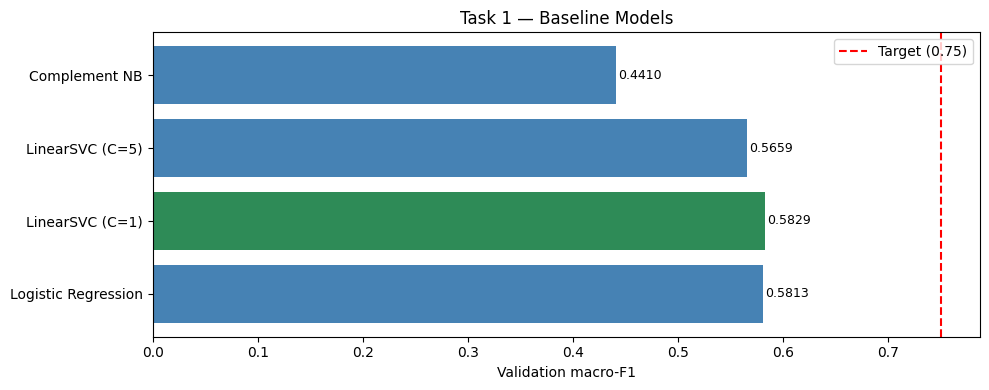

Saved: pred_t1_model_comparison.png


In [ ]:
# ── CELL 11: Task 1 — Baseline model comparison ──────────────────────────────
t1_results = {}

# Logistic Regression
print('Training Logistic Regression...')
lr1 = LogisticRegression(C=5, class_weight='balanced', max_iter=300, solver='lbfgs', n_jobs=-1, random_state=42)
lr1.fit(Xtr1, ytr1)
t1_results['Logistic Regression'] = f1_score(yv1, lr1.predict(Xv1), average='macro')
print(f'  LR C=5:  {t1_results["Logistic Regression"]:.4f}')

# LinearSVC C=1
print('Training LinearSVC (C=1)...')
svc1 = LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=42)
svc1.fit(Xtr1, ytr1)
t1_results['LinearSVC (C=1)'] = f1_score(yv1, svc1.predict(Xv1), average='macro')
print(f'  SVC C=1: {t1_results["LinearSVC (C=1)"]:.4f}')

# LinearSVC C=5
print('Training LinearSVC (C=5)...')
svc1b = LinearSVC(C=5.0, class_weight='balanced', max_iter=3000, random_state=42)
svc1b.fit(Xtr1, ytr1)
t1_results['LinearSVC (C=5)'] = f1_score(yv1, svc1b.predict(Xv1), average='macro')
print(f'  SVC C=5: {t1_results["LinearSVC (C=5)"]:.4f}')

# Complement NB
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
Xtr1_nb = scaler.fit_transform(Xtr1)
Xv1_nb  = scaler.transform(Xv1)
Xte1_nb = scaler.transform(Xte1)
cnb1 = ComplementNB(alpha=0.1)
cnb1.fit(Xtr1_nb, ytr1)
t1_results['Complement NB'] = f1_score(yv1, cnb1.predict(Xv1_nb), average='macro')
print(f'  NB:      {t1_results["Complement NB"]:.4f}')

# Pick best
best_t1_name = max(t1_results, key=t1_results.get)
model_map_t1 = {
    'Logistic Regression': (lr1,   Xte1),
    'LinearSVC (C=1)':     (svc1,  Xte1),
    'LinearSVC (C=5)':     (svc1b, Xte1),
    'Complement NB':       (cnb1,  Xte1_nb),
}
best_t1_model, best_t1_X = model_map_t1[best_t1_name]

print(f'\n🏆 Best Task 1 baseline: {best_t1_name} — val F1: {t1_results[best_t1_name]:.4f}')

# Chart
fig, ax = plt.subplots(figsize=(10, 4))
names  = list(t1_results.keys())
scores = list(t1_results.values())
colors = ['seagreen' if n == best_t1_name else 'steelblue' for n in names]
bars   = ax.barh(names, scores, color=colors)
ax.axvline(0.75, color='red', linestyle='--', linewidth=1.5, label='Target (0.75)')
ax.set_xlabel('Validation macro-F1')
ax.set_title('Task 1 — Baseline Models')
ax.legend()
for bar, score in zip(bars, scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2, f'{score:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('pred_t1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pred_t1_model_comparison.png')

Task 1 baseline test macro-F1: 0.5673


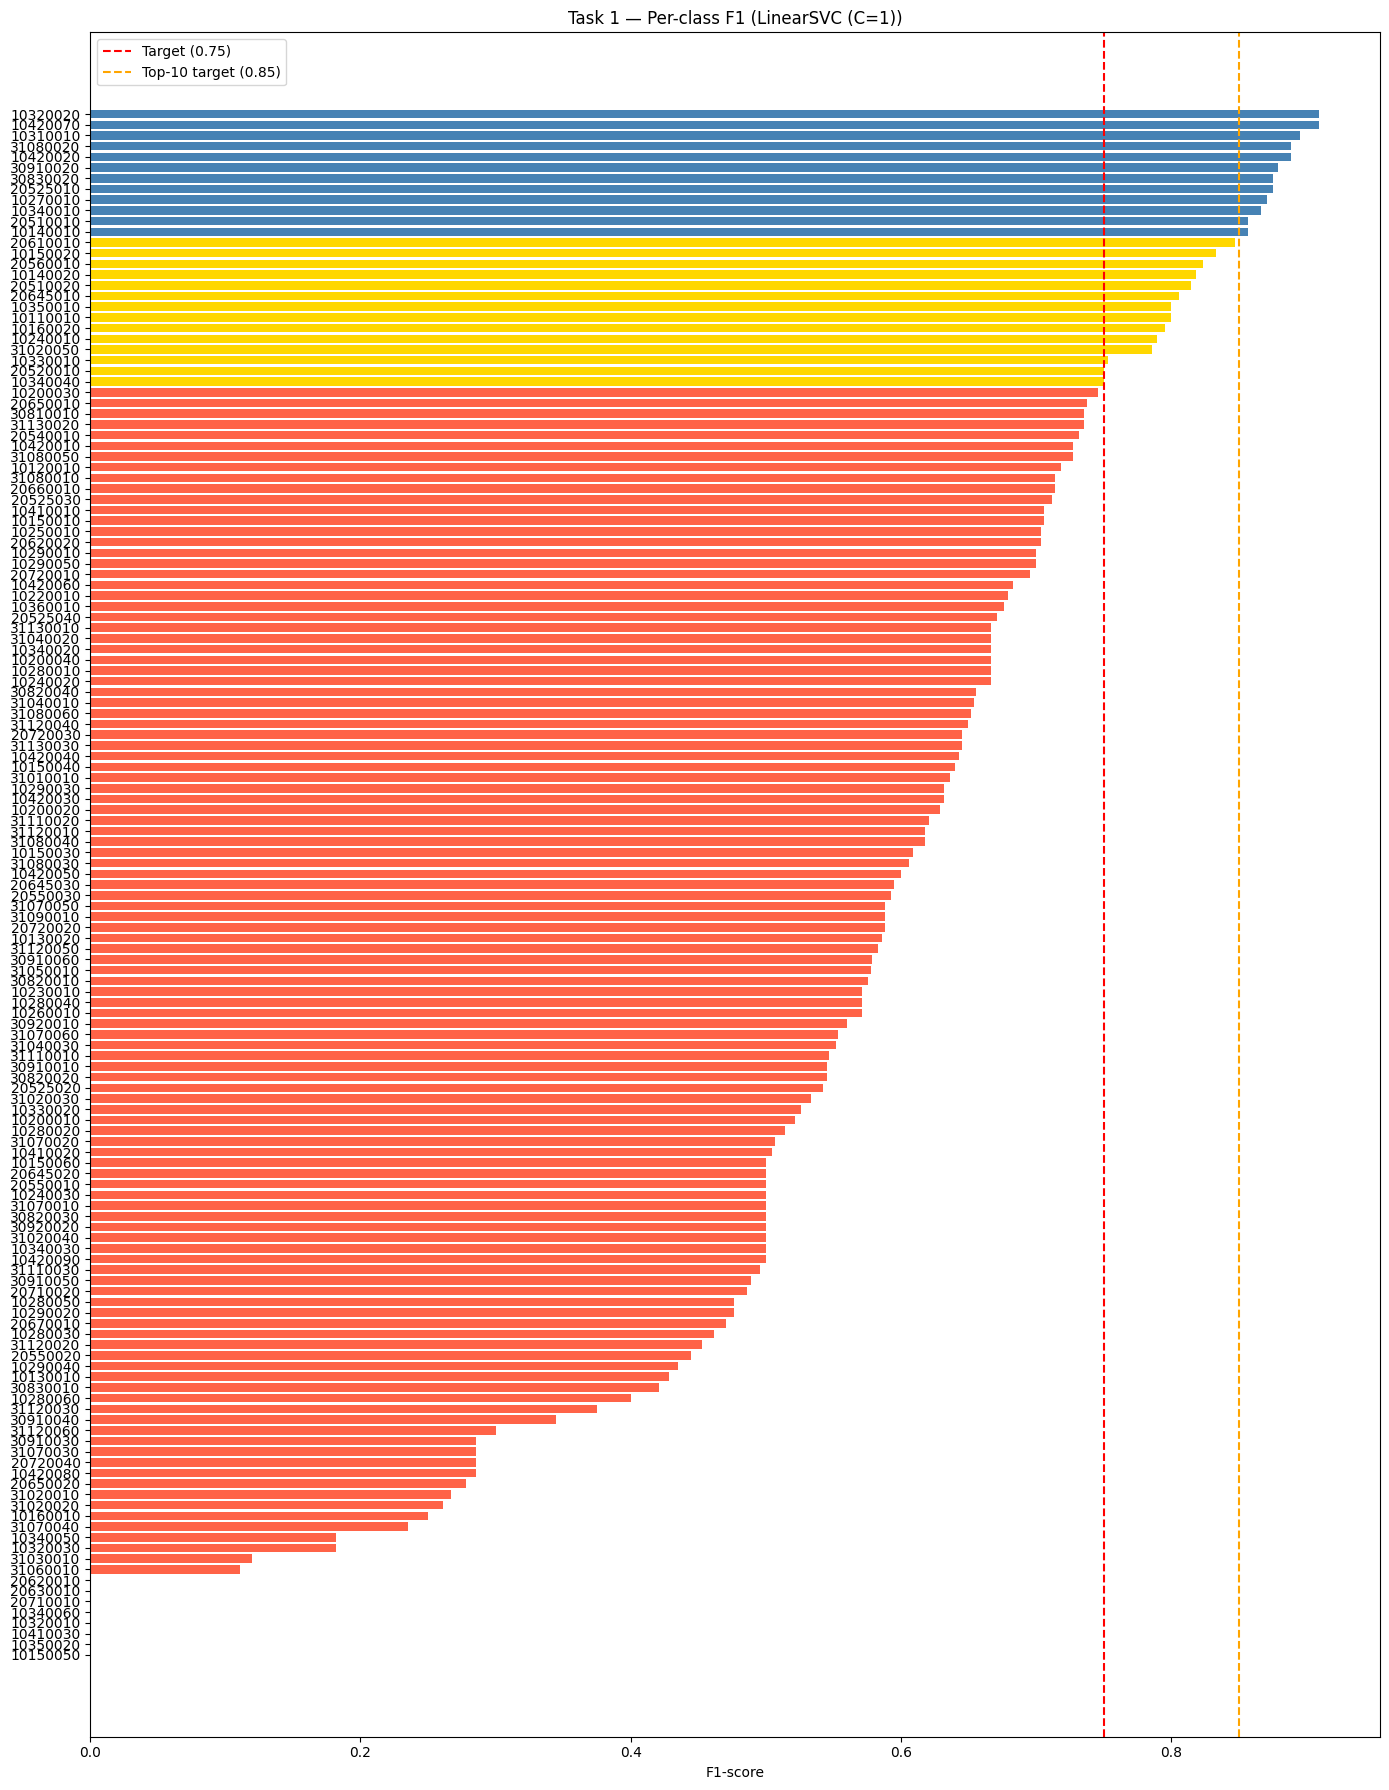

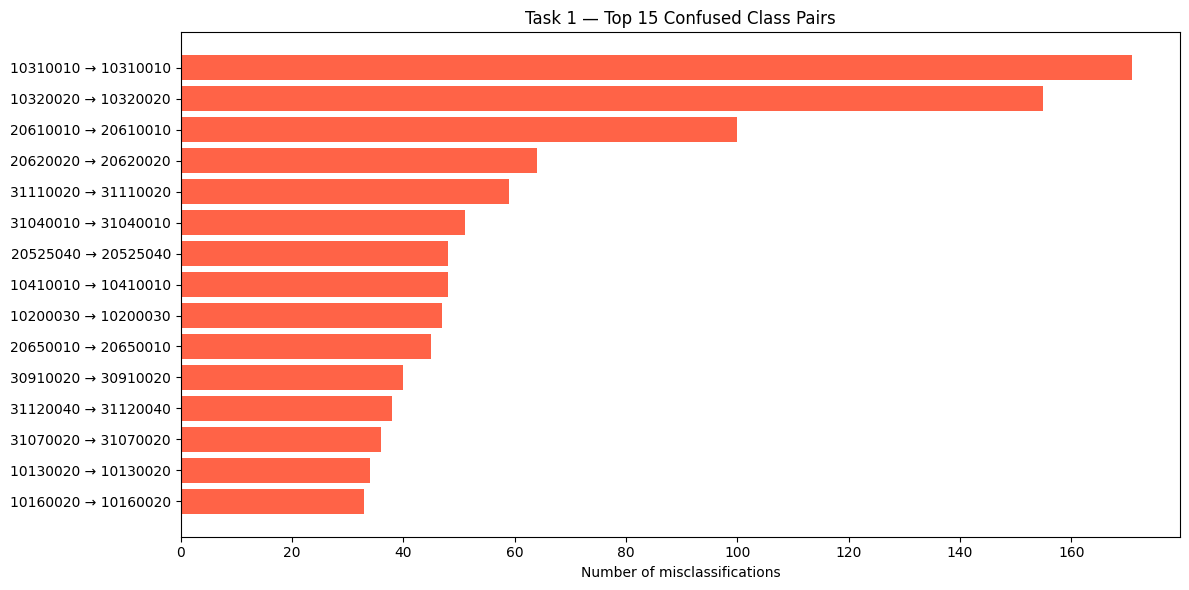

Saved: pred_t1_per_class_f1.png and pred_t1_confusion_pairs.png


In [ ]:
# ── CELL 12: Task 1 — Baseline test evaluation ───────────────────────────────
t1_preds   = best_t1_model.predict(best_t1_X)
t1_macro   = f1_score(yte1, t1_preds, average='macro')
t1_weighted= f1_score(yte1, t1_preds, average='weighted')

print(f'Task 1 baseline test macro-F1: {t1_macro:.4f}')
t1_report    = classification_report(yte1, t1_preds, output_dict=True)
t1_report_df = pd.DataFrame(t1_report).transpose()
t1_report_df.to_csv('task1_per_class_results.csv')

# Per-class chart
rdf = t1_report_df.drop(['accuracy','macro avg','weighted avg'], errors='ignore')
rdf = rdf[rdf['support'] > 0].sort_values('f1-score')
fig, ax = plt.subplots(figsize=(14, 18))
colors = ['tomato' if f < 0.75 else ('gold' if f < 0.85 else 'steelblue') for f in rdf['f1-score']]
ax.barh(rdf.index.astype(str), rdf['f1-score'], color=colors)
ax.axvline(0.75, color='red',    linestyle='--', linewidth=1.5, label='Target (0.75)')
ax.axvline(0.85, color='orange', linestyle='--', linewidth=1.5, label='Top-10 target (0.85)')
ax.set_xlabel('F1-score')
ax.set_title(f'Task 1 — Per-class F1 ({best_t1_name})')
ax.legend()
plt.tight_layout()
plt.savefig('pred_t1_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion pairs
errors1 = test1.copy()
errors1['predicted'] = t1_preds
errors1 = errors1[errors1['predicted'] != errors1['MstarGlobal'].astype(str)]
conf1 = (errors1.groupby([errors1['MstarGlobal'].astype(str), errors1['predicted']])
                .size().reset_index(name='count').rename(columns={'MstarGlobal':'actual'}))
conf1['pair'] = conf1['actual'] + ' → ' + conf1['predicted'].astype(str)
conf1 = conf1.sort_values('count', ascending=False).head(15)
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.barh(conf1['pair'], conf1['count'], color='tomato')
ax2.set_xlabel('Number of misclassifications')
ax2.set_title(f'Task 1 — Top 15 Confused Class Pairs')
ax2.invert_yaxis()
plt.tight_layout()
plt.savefig('pred_t1_confusion_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pred_t1_per_class_f1.png and pred_t1_confusion_pairs.png')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TASK 2 — Subindustry Classification
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
# ── CELL 13: Task 2 — Feature engineering ────────────────────────────────────
def build_text_t2(row):
    name = str(row['SegmentName']).strip()
    desc = str(row['SegmentDescription']).strip()
    if not desc or desc.lower() == 'nan':
        return (name + ' ') * 3
    return (name + ' ') * 3 + desc

df2['combined_text'] = df2.apply(build_text_t2, axis=1)
df2['year']          = pd.to_datetime(df2['AsOfDate']).dt.year

cc2 = df2['SubIndustry'].value_counts()
print(f'Class distribution: min={cc2.min()}, max={cc2.max()}, median={cc2.median():.0f}')
print('Features built ✓')

Class distribution: min=1, max=2018, median=30
Features built ✓


In [ ]:
# ── CELL 14: Task 2 — Split 80/10/10  ──────────────
cc2  = df2['SubIndustry'].value_counts()
rare = cc2[cc2 < 10].index.tolist()
print(f'Rare classes (<10 examples): {len(rare)} → forced into training only')

rare_df2 = df2[df2['SubIndustry'].isin(rare)].copy()
main_df2 = df2[~df2['SubIndustry'].isin(rare)].copy()

train2, temp2 = train_test_split(
    main_df2, test_size=0.20,
    stratify=main_df2['SubIndustry'], random_state=42)
val2, test2 = train_test_split(
    temp2, test_size=0.50,
    stratify=temp2['SubIndustry'], random_state=42)

train2 = pd.concat([train2, rare_df2], ignore_index=True)

print(f'Train: {len(train2):,} (80%) | Val: {len(val2):,} (10%) | Test: {len(test2):,} (10%)')
print(f'Classes in train: {train2["SubIndustry"].nunique()} | test: {test2["SubIndustry"].nunique()}')
ytr2, yv2, yte2 = train2['SubIndustry'], val2['SubIndustry'], test2['SubIndustry']

Rare classes (<10 examples): 99 → forced into training only
Train: 22,113 (80%) | Val: 2,712 (10%) | Test: 2,712 (10%)
Classes in train: 428 | test: 329


In [ ]:
# ── CELL 15: Task 2 — TF-IDF feature matrix ──────────────────────────────────
print('Building word TF-IDF...')
wtf2 = TfidfVectorizer(max_features=40000, ngram_range=(1,3), sublinear_tf=True, min_df=1, analyzer='word')
print('Building character TF-IDF...')
ctf2 = TfidfVectorizer(max_features=20000, ngram_range=(3,5), sublinear_tf=True, min_df=2, analyzer='char_wb')

wtf2.fit(train2['combined_text'])
ctf2.fit(train2['combined_text'])

def make_X2(df):
    return hstack([wtf2.transform(df['combined_text']), ctf2.transform(df['combined_text'])])

Xtr2, Xv2, Xte2 = make_X2(train2), make_X2(val2), make_X2(test2)
print(f'Feature matrix shape: {Xtr2.shape}')
print('Features ready ✓')

Building word TF-IDF...
Building character TF-IDF...
Feature matrix shape: (22113, 60000)
Features ready ✓


Training LinearSVC (C=0.5)...
  0.3577
Training LinearSVC (C=1.0)...
  0.3694
Training Logistic Regression...
  0.3941

🏆 Best Task 2 baseline: Logistic Regression — test macro-F1: 0.4368


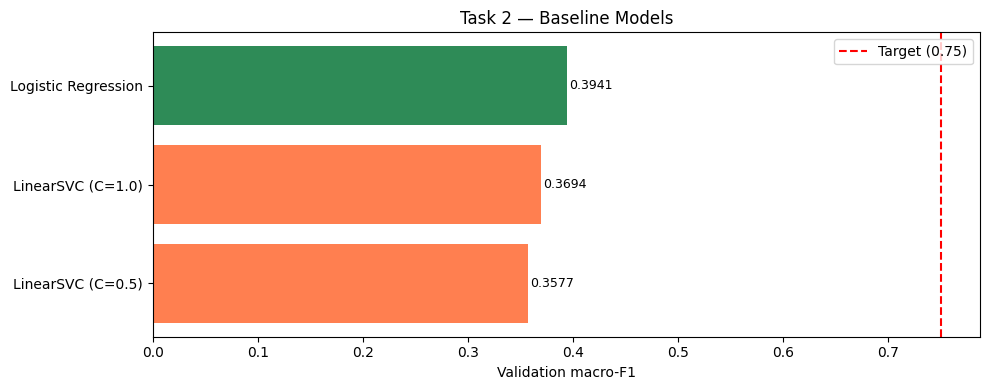

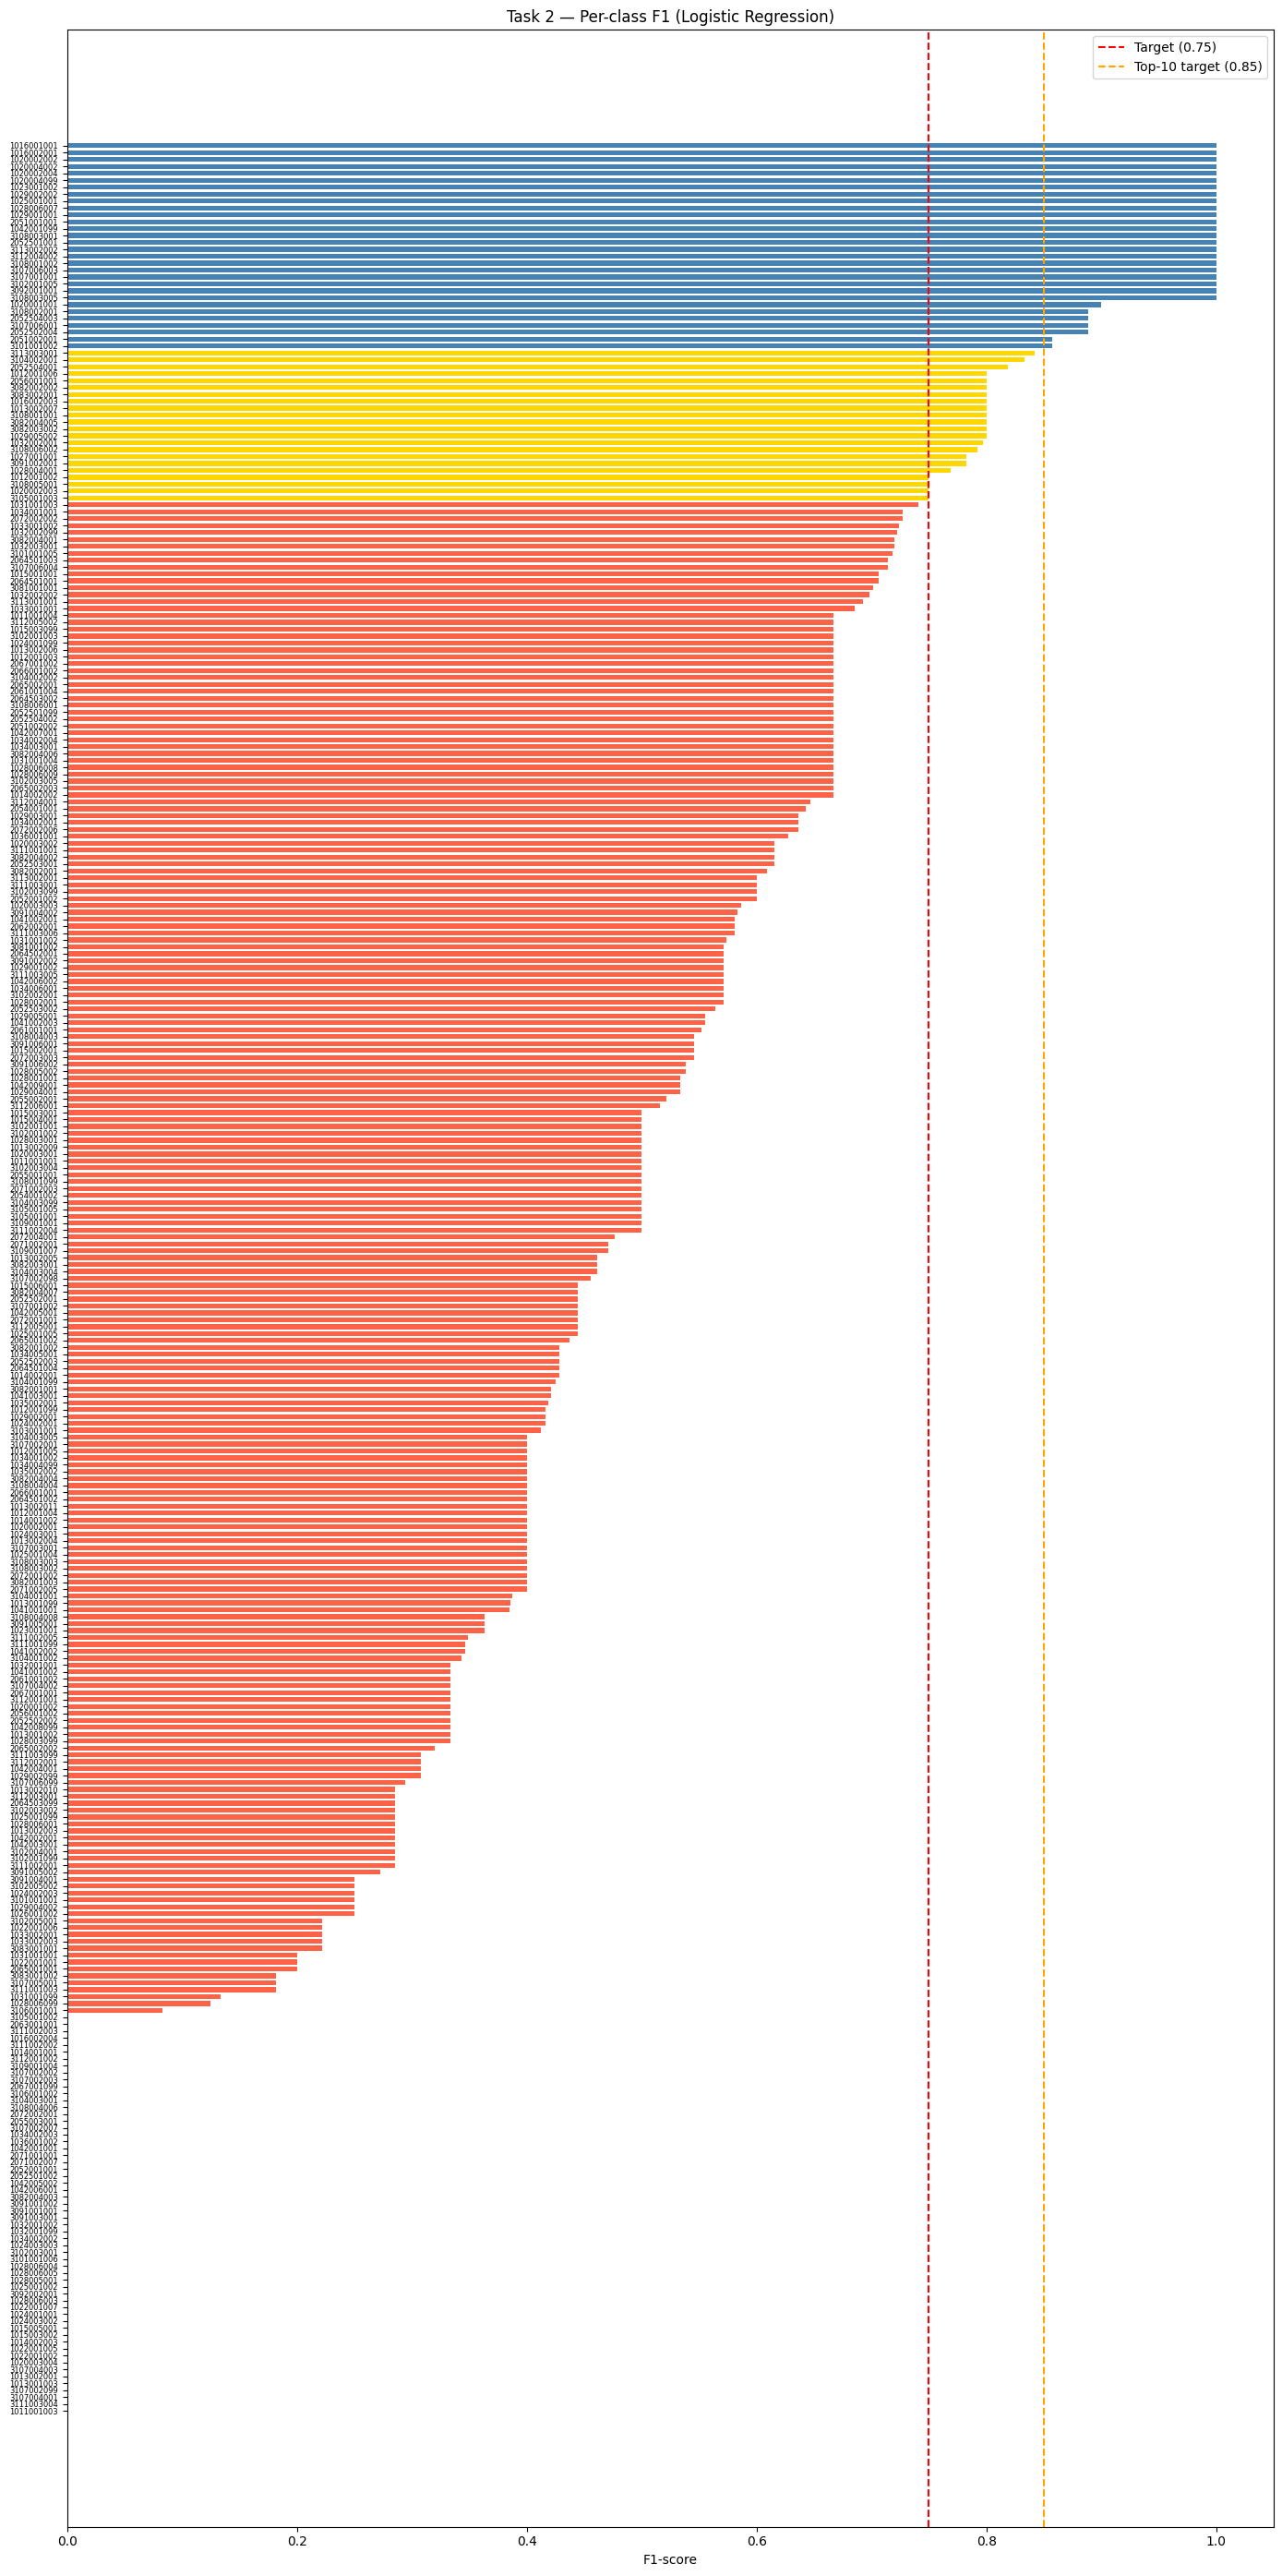

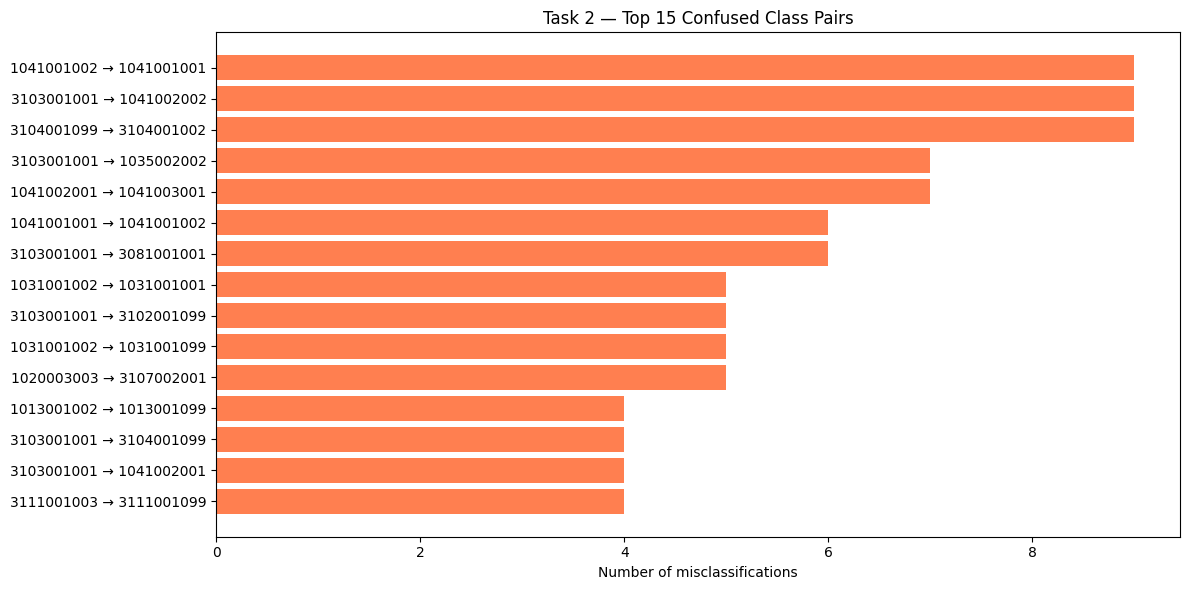

Saved: pred_t2_per_class_f1.png and pred_t2_confusion_pairs.png


In [ ]:
# ── CELL 16: Task 2 — Baseline models ────────────────────────────────────────
t2_results = {}

print('Training LinearSVC (C=0.5)...')
svc2a = LinearSVC(C=0.5, class_weight='balanced', max_iter=3000, random_state=42)
svc2a.fit(Xtr2, ytr2)
t2_results['LinearSVC (C=0.5)'] = f1_score(yv2, svc2a.predict(Xv2), average='macro')
print(f'  {t2_results["LinearSVC (C=0.5)"]:.4f}')

print('Training LinearSVC (C=1.0)...')
svc2b = LinearSVC(C=1.0, class_weight='balanced', max_iter=3000, random_state=42)
svc2b.fit(Xtr2, ytr2)
t2_results['LinearSVC (C=1.0)'] = f1_score(yv2, svc2b.predict(Xv2), average='macro')
print(f'  {t2_results["LinearSVC (C=1.0)"]:.4f}')

print('Training Logistic Regression...')
lr2 = LogisticRegression(C=5, class_weight='balanced', max_iter=300, solver='lbfgs', n_jobs=-1, random_state=42)
lr2.fit(Xtr2, ytr2)
t2_results['Logistic Regression'] = f1_score(yv2, lr2.predict(Xv2), average='macro')
print(f'  {t2_results["Logistic Regression"]:.4f}')

best_t2_name  = max(t2_results, key=t2_results.get)
best_t2_model = {'LinearSVC (C=0.5)': svc2a, 'LinearSVC (C=1.0)': svc2b, 'Logistic Regression': lr2}[best_t2_name]

t2_preds   = best_t2_model.predict(Xte2)
t2_macro   = f1_score(yte2, t2_preds, average='macro')
t2_weighted= f1_score(yte2, t2_preds, average='weighted')
print(f'\n🏆 Best Task 2 baseline: {best_t2_name} — test macro-F1: {t2_macro:.4f}')

t2_report    = classification_report(yte2, t2_preds, output_dict=True)
t2_report_df = pd.DataFrame(t2_report).transpose()
t2_report_df.to_csv('task2_per_class_results.csv')

# Chart
fig, ax = plt.subplots(figsize=(10, 4))
names  = list(t2_results.keys())
scores = list(t2_results.values())
colors = ['seagreen' if n == best_t2_name else 'coral' for n in names]
bars   = ax.barh(names, scores, color=colors)
ax.axvline(0.75, color='red', linestyle='--', linewidth=1.5, label='Target (0.75)')
ax.set_xlabel('Validation macro-F1')
ax.set_title('Task 2 — Baseline Models')
ax.legend()
for bar, score in zip(bars, scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2, f'{score:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('pred_t2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class chart
rdf2 = t2_report_df.drop(['accuracy','macro avg','weighted avg'], errors='ignore')
rdf2 = rdf2[rdf2['support'] > 0].sort_values('f1-score')
fig, ax = plt.subplots(figsize=(14, 28))
colors2 = ['tomato' if f < 0.75 else ('gold' if f < 0.85 else 'steelblue') for f in rdf2['f1-score']]
ax.barh(rdf2.index.astype(str), rdf2['f1-score'], color=colors2, height=0.7)
ax.axvline(0.75, color='red',    linestyle='--', linewidth=1.5, label='Target (0.75)')
ax.axvline(0.85, color='orange', linestyle='--', linewidth=1.5, label='Top-10 target (0.85)')
ax.set_xlabel('F1-score')
ax.set_title(f'Task 2 — Per-class F1 ({best_t2_name})')
ax.tick_params(axis='y', labelsize=6)
ax.legend()
plt.tight_layout()
plt.savefig('pred_t2_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion pairs
errors2 = test2.copy()
errors2['predicted'] = t2_preds
errors2 = errors2[errors2['predicted'] != errors2['SubIndustry'].astype(str)]
conf2 = (errors2.groupby([errors2['SubIndustry'].astype(str), errors2['predicted']])
                .size().reset_index(name='count').rename(columns={'SubIndustry': 'actual'}))
conf2['pair'] = conf2['actual'] + ' → ' + conf2['predicted'].astype(str)
conf2 = conf2.sort_values('count', ascending=False).head(15)
fig3, ax3 = plt.subplots(figsize=(12, 6))
ax3.barh(conf2['pair'], conf2['count'], color='coral')
ax3.set_xlabel('Number of misclassifications')
ax3.set_title('Task 2 — Top 15 Confused Class Pairs')
ax3.invert_yaxis()
plt.tight_layout()
plt.savefig('pred_t2_confusion_pairs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pred_t2_per_class_f1.png and pred_t2_confusion_pairs.png')

In [ ]:
# ── CELL 17: Baseline summary ─────────────────────────────────────────────────
print('='*60)
print('  BASELINE RESULTS SUMMARY')
print('='*60)
print(f'  Task 1 — {best_t1_name:<30} test macro-F1: {t1_macro:.4f}')
print(f'  Task 2 — {best_t2_name:<30} test macro-F1: {t2_macro:.4f}')
print(f'  Target: ≥ 0.75 for both tasks')
print('='*60)

  BASELINE RESULTS SUMMARY
  Task 1 — LinearSVC (C=1)                test macro-F1: 0.5673
  Task 2 — Logistic Regression            test macro-F1: 0.4368
  Target: ≥ 0.75 for both tasks


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SENTENCE EMBEDDINGS UPGRADE
# ══════════════════════════════════════════════════════════════════════════════

In [ ]:
# ── CELL 18: Install sentence-transformers & load model ───────────────────────
!pip install sentence-transformers --quiet
import torch
from sentence_transformers import SentenceTransformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'GPU available: {torch.cuda.is_available()}')
print(f'Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

model = SentenceTransformer('all-MiniLM-L6-v2')
model = model.to(device)
print(f'MiniLM loaded on {device}  (384-dim)')

model_v2 = SentenceTransformer('all-mpnet-base-v2')
model_v2 = model_v2.to(device)
print(f'mpnet loaded on {device}   (768-dim)')

GPU available: False
Device: CPU


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

mpnet loaded on cpu   (768-dim)


In [ ]:
# ── CELL 19: Task 1 — Encode with MiniLM & train combo model ─────────────────
def encode_texts(mdl, texts, batch_size=256):
    return mdl.encode(texts.tolist(), batch_size=batch_size,
                      show_progress_bar=True, device=device, normalize_embeddings=True)

def add_numeric_t1(emb, df):
    num = df[['revenue_share','is_largest_flag','has_seg_desc']].values.astype(np.float32)
    return np.hstack([emb, num])

print('Encoding Task 1 with MiniLM...')
emb_tr1 = encode_texts(model, train1['combined_text'])
emb_v1  = encode_texts(model, val1['combined_text'])
emb_te1 = encode_texts(model, test1['combined_text'])

from scipy.sparse import hstack as sp_hstack, csr_matrix

Xtr1_tfidf_only = tfidf1.transform(train1['combined_text'])
Xv1_tfidf_only  = tfidf1.transform(val1['combined_text'])
Xte1_tfidf_only = tfidf1.transform(test1['combined_text'])

Xtr1_combo = sp_hstack([Xtr1_tfidf_only, csr_matrix(add_numeric_t1(emb_tr1, train1))])
Xv1_combo  = sp_hstack([Xv1_tfidf_only,  csr_matrix(add_numeric_t1(emb_v1,  val1))])
Xte1_combo = sp_hstack([Xte1_tfidf_only, csr_matrix(add_numeric_t1(emb_te1, test1))])

print('Training Task 1 TF-IDF + MiniLM combo...')
lr1_combo = LogisticRegression(C=5, class_weight='balanced', max_iter=1000,
                                solver='lbfgs', n_jobs=-1, random_state=42)
lr1_combo.fit(Xtr1_combo, ytr1)

t1_combo_val  = f1_score(yv1,  lr1_combo.predict(Xv1_combo),  average='macro')
t1_final_macro = f1_score(yte1, lr1_combo.predict(Xte1_combo), average='macro')
t1_final_weighted = f1_score(yte1, lr1_combo.predict(Xte1_combo), average='weighted')

print(f'\nTask 1 TF-IDF + MiniLM test macro-F1: {t1_final_macro:.4f}')
print(f'vs TF-IDF baseline:                    {t1_macro:.4f}  (+{t1_final_macro-t1_macro:+.4f})')

# Top 10 check
t1_final_report = classification_report(yte1, lr1_combo.predict(Xte1_combo), output_dict=True)
top10_t1 = pd.Series(yte1).value_counts().head(10).index.tolist()
print('\n=== Top 10 classes ===')
for cls in top10_t1:
    score = t1_final_report.get(str(cls), {}).get('f1-score', 0)
    print(f'  {"✅" if score > 0.85 else "⚠️ "} {cls}: {score:.4f}')

In [ ]:
# ── CELL 20: Upload GECS Activities 2026 ─────────────────────────────────────
from google.colab import files
import openpyxl

print('Upload GECS_Activities2026.xlsx')
uploaded_gecs = files.upload()

gecs_raw = pd.read_excel(
    list(uploaded_gecs.keys())[0],
    sheet_name='GECS Activties (Revised)')

gecs_agg = (
    gecs_raw.groupby('Industry ID').agg(
        industry_name  = ('Industry', 'first'),
        all_activities = ('Activity', lambda x: ' '.join(x)),
        all_definitions= ('Activity Definition', lambda x: ' '.join(x))
    ).reset_index()
)
gecs_agg['full_knowledge'] = (
    gecs_agg['industry_name'] + '. ' +
    gecs_agg['all_activities'] + '. ' +
    gecs_agg['all_definitions']
)
gecs_agg['Industry ID'] = gecs_agg['Industry ID'].astype(str)

print(f'Knowledge base: {len(gecs_agg)} industries')

Upload GECS_Activities2026.xlsx


Saving GECS_Activities2026.xlsx to GECS_Activities2026.xlsx
Knowledge base: 145 industries


In [ ]:
# ── CELL 21: Task 2 — Augment training texts with GECS knowledge ─────────────
knowledge_lookup = dict(zip(gecs_agg['Industry ID'], gecs_agg['full_knowledge']))

def augment_text(row, lookup):
    base     = str(row['combined_text'])
    industry = str(row['SubIndustry'])
    knowledge= lookup.get(industry, '')
    if knowledge:
        return base + ' [INDUSTRY CONTEXT] ' + knowledge
    return base

# Augment TRAINING only — no leakage
train2['augmented_text'] = train2.apply(lambda r: augment_text(r, knowledge_lookup), axis=1)
val2['augmented_text']   = val2['combined_text']
test2['augmented_text']  = test2['combined_text']

print(f'Training texts augmented: {len(train2):,}')

Training texts augmented: 22,113


In [ ]:
# ── CELL 22: Task 2 — Encode with MiniLM ─────────────────────────────────────
def encode_texts(mdl, texts, batch_size=256):
    return mdl.encode(texts.tolist(), batch_size=batch_size,
                      show_progress_bar=True, device=device, normalize_embeddings=True)

print('Encoding Task 2 with MiniLM (augmented training)...')
emb_tr2 = encode_texts(model, train2['augmented_text'])
emb_v2  = encode_texts(model, val2['augmented_text'])
emb_te2 = encode_texts(model, test2['augmented_text'])
print(f'Shapes: train={emb_tr2.shape}, val={emb_v2.shape}, test={emb_te2.shape}')

print('\nEncoding Task 2 with mpnet...')
emb_tr2_v2 = encode_texts(model_v2, train2['augmented_text'], batch_size=128)
emb_v2_v2  = encode_texts(model_v2, val2['augmented_text'],   batch_size=128)
emb_te2_v2 = encode_texts(model_v2, test2['augmented_text'],  batch_size=128)
print(f'Shapes: train={emb_tr2_v2.shape}, val={emb_v2_v2.shape}, test={emb_te2_v2.shape}')

Encoding Task 2 with MiniLM (augmented training)...


Batches:   0%|          | 0/87 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Shapes: train=(22113, 384), val=(2712, 384), test=(2712, 384)

Encoding Task 2 with mpnet...


Batches:   0%|          | 0/173 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── CELL 23: Task 2 — Train embedding-based classifiers ──────────────────────
t2_emb_results = {}

# TF-IDF + MiniLM combo
Xtr2_combo = sp_hstack([wtf2.transform(train2['combined_text']), csr_matrix(emb_tr2)])
Xv2_combo  = sp_hstack([wtf2.transform(val2['combined_text']),   csr_matrix(emb_v2)])
Xte2_combo = sp_hstack([wtf2.transform(test2['combined_text']),  csr_matrix(emb_te2)])

print('Training LR on TF-IDF + MiniLM...')
lr2_combo = LogisticRegression(C=5, class_weight='balanced', max_iter=1000,
                                solver='lbfgs', n_jobs=-1, random_state=42)
lr2_combo.fit(Xtr2_combo, ytr2)
t2_emb_results['TF-IDF + MiniLM'] = f1_score(yv2, lr2_combo.predict(Xv2_combo), average='macro')
print(f'  val: {t2_emb_results["TF-IDF + MiniLM"]:.4f}')

print(f'\nTask 2 best embedding approach: {max(t2_emb_results, key=t2_emb_results.get)}')
print(f'val macro-F1: {max(t2_emb_results.values()):.4f}')

In [ ]:
# ── CELL 24: Task 2 — Final test evaluation ───────────────────────────────────
t2_final_preds    = lr2_combo.predict(Xte2_combo)
t2_final_macro    = f1_score(yte2, t2_final_preds, average='macro')
t2_final_weighted = f1_score(yte2, t2_final_preds, average='weighted')

print(f'Task 2 TF-IDF + MiniLM test macro-F1: {t2_final_macro:.4f}')
print(f'vs baseline:                           {t2_macro:.4f}  ({t2_final_macro-t2_macro:+.4f})')

In [ ]:
# ── CELL 25: Task 2 — Probability ensemble (best result) ─────────────────────
print('Building probability ensemble (TF-IDF + MiniLM, C=1/5/10)...')

lr_e1 = LogisticRegression(C=5,  class_weight='balanced', max_iter=1000, solver='lbfgs', n_jobs=-1, random_state=42)
lr_e2 = LogisticRegression(C=1,  class_weight='balanced', max_iter=1000, solver='lbfgs', n_jobs=-1, random_state=42)
lr_e3 = LogisticRegression(C=10, class_weight='balanced', max_iter=1000, solver='lbfgs', n_jobs=-1, random_state=42)

lr_e1.fit(Xtr2_combo, ytr2)
lr_e2.fit(Xtr2_combo, ytr2)
lr_e3.fit(Xtr2_combo, ytr2)

classes  = lr_e1.classes_
avg_test = (lr_e1.predict_proba(Xte2_combo) +
            lr_e2.predict_proba(Xte2_combo) +
            lr_e3.predict_proba(Xte2_combo)) / 3

ens_test_preds = classes[np.argmax(avg_test, axis=1)]
ens_test_f1    = f1_score(yte2, ens_test_preds, average='macro')

print(f'\nEnsemble test macro-F1: {ens_test_f1:.4f}')
print(f'vs TF-IDF+MiniLM:       {t2_final_macro:.4f}')

# Top 10 check
t2_ens_report = classification_report(yte2, ens_test_preds, output_dict=True)
top10_t2 = pd.Series(yte2).value_counts().head(10).index.tolist()
print('\n=== Top 10 classes ===')
for cls in top10_t2:
    score = t2_ens_report.get(str(cls), {}).get('f1-score', 0)
    print(f'  {"✅" if score > 0.85 else "⚠️ "} {cls}: {score:.4f}')

In [ ]:
# ── CELL 26: RoBERTa fine-tuning — Task 1 ────────────────────────────────────
!pip install transformers accelerate -q

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from torch import nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_name = 'roberta-base'
tokenizer  = AutoTokenizer.from_pretrained(model_name)

le = LabelEncoder()
y_train_enc = le.fit_transform(train1['MstarGlobal'])
y_val_enc   = le.transform(val1['MstarGlobal'])
y_test_enc  = le.transform(test1['MstarGlobal'])
n_classes   = len(le.classes_)
print(f'Classes: {n_classes}')

def tokenize(texts, max_length=256):
    return tokenizer(texts.tolist(), truncation=True, padding=True,
                     max_length=max_length, return_tensors='pt')

print('Tokenizing...')
tr_enc = tokenize(train1['combined_text'])
v_enc  = tokenize(val1['combined_text'])
te_enc = tokenize(test1['combined_text'])

class GECSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = GECSDataset(tr_enc, y_train_enc)
val_ds   = GECSDataset(v_enc,  y_val_enc)
test_ds  = GECSDataset(te_enc, y_test_enc)

class_weights  = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=n_classes, ignore_mismatched_sizes=True)
roberta_model = roberta_model.to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(weight=weights_tensor)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'macro_f1': f1_score(labels, preds, average='macro')}

training_args = TrainingArguments(
    output_dir='./roberta_gecs',
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=200,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    fp16=True,
    logging_steps=50,
    report_to='none'
)

trainer = WeightedTrainer(
    model=roberta_model, args=training_args,
    train_dataset=train_ds, eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

print('Starting RoBERTa fine-tuning (expect ~90 min on A100)...')
trainer.train()

preds_out      = trainer.predict(test_ds)
y_pred_enc     = np.argmax(preds_out.predictions, axis=1)
roberta_t1_f1  = f1_score(y_test_enc, y_pred_enc, average='macro')
print(f'\nRoBERTa fine-tuned test macro-F1: {roberta_t1_f1:.4f}')
print(f'vs TF-IDF + MiniLM:               {t1_final_macro:.4f}')

In [ ]:
# ── CELL 27: Final results summary ───────────────────────────────────────────
print()
print('='*65)
print('  FINAL RESULTS SUMMARY')
print('='*65)
print(f'  Task 1 — TF-IDF baseline:           {t1_macro:.4f}')
print(f'  Task 1 — TF-IDF + MiniLM:           {t1_final_macro:.4f}  ← best')
print(f'  Task 1 — RoBERTa fine-tuned:         {roberta_t1_f1:.4f}')
print()
print(f'  Task 2 — TF-IDF baseline:           {t2_macro:.4f}')
print(f'  Task 2 — TF-IDF + MiniLM ensemble:  {ens_test_f1:.4f}  ← best')
print()
print(f'  Target (both tasks): ≥ 0.75')
print('='*65)

# Final chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline vs Upgraded Results', fontsize=14, fontweight='bold')

for ax, (task, base, final) in zip(axes, [
    ('Task 1', t1_macro, t1_final_macro),
    ('Task 2', t2_macro, ens_test_f1),
]):
    bars = ax.bar(['Baseline', 'Upgraded'], [base, final],
                  color=['steelblue', 'seagreen'], width=0.4)
    ax.axhline(0.75, color='red', linestyle='--', linewidth=1.5, label='Target (0.75)')
    ax.set_ylim(0, 1.0)
    ax.set_title(f'{task} — Macro-F1')
    ax.set_ylabel('Macro-F1')
    ax.legend()
    for bar, val in zip(bars, [base, final]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('final_summary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_summary_comparison.png')